In [1]:
import pandas as pd
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("leyes_contratos") \
    .getOrCreate()

contratos_pd = pd.read_excel('contratos_clasificados.xlsx')
leyes_pd = pd.read_excel('leyes_clasificadas.xlsx')

# Convertir a Spark DataFrame
contratos_spark = spark.createDataFrame(contratos_pd)
leyes_spark = spark.createDataFrame(leyes_pd)

contratos_spark.createOrReplaceTempView("contratos")
leyes_spark.createOrReplaceTempView("leyes")

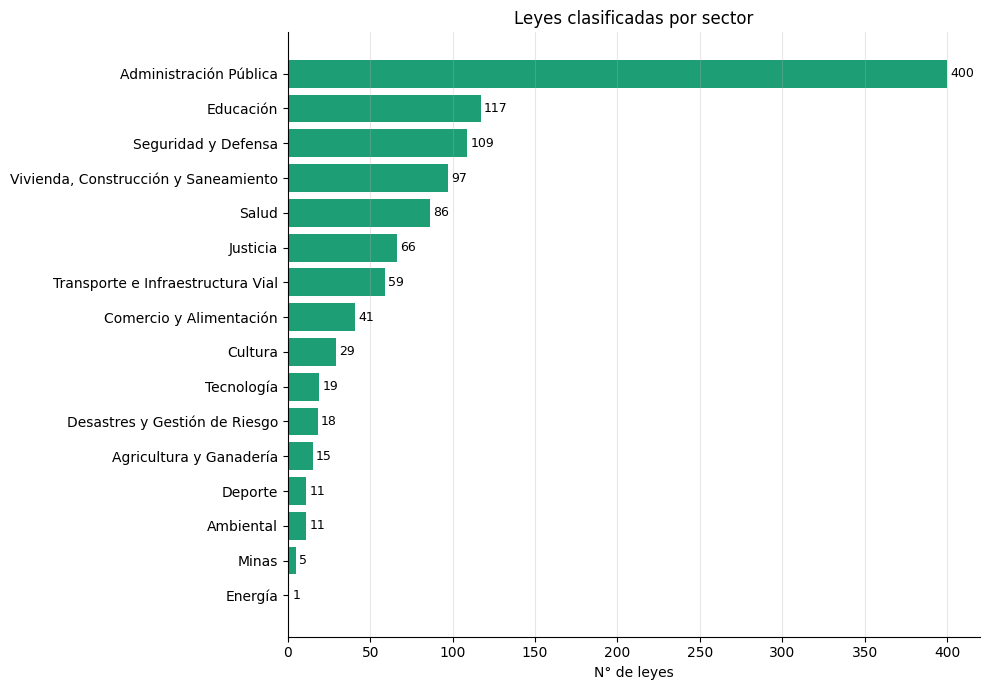

In [2]:
import matplotlib.pyplot as plt

df_leyes = spark.sql("""
    SELECT sector_clasificado, COUNT(*) AS n_leyes
    FROM leyes
    WHERE sector_clasificado != 'Sin clasificar'
    GROUP BY sector_clasificado
    ORDER BY n_leyes ASC
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_leyes['sector_clasificado'], df_leyes['n_leyes'],
               color='#1D9E75', edgecolor='none')

for bar, val in zip(bars, df_leyes['n_leyes']):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('N° de leyes')
ax.set_title('Leyes clasificadas por sector')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('leyes_por_sector.png', dpi=150)
plt.show()

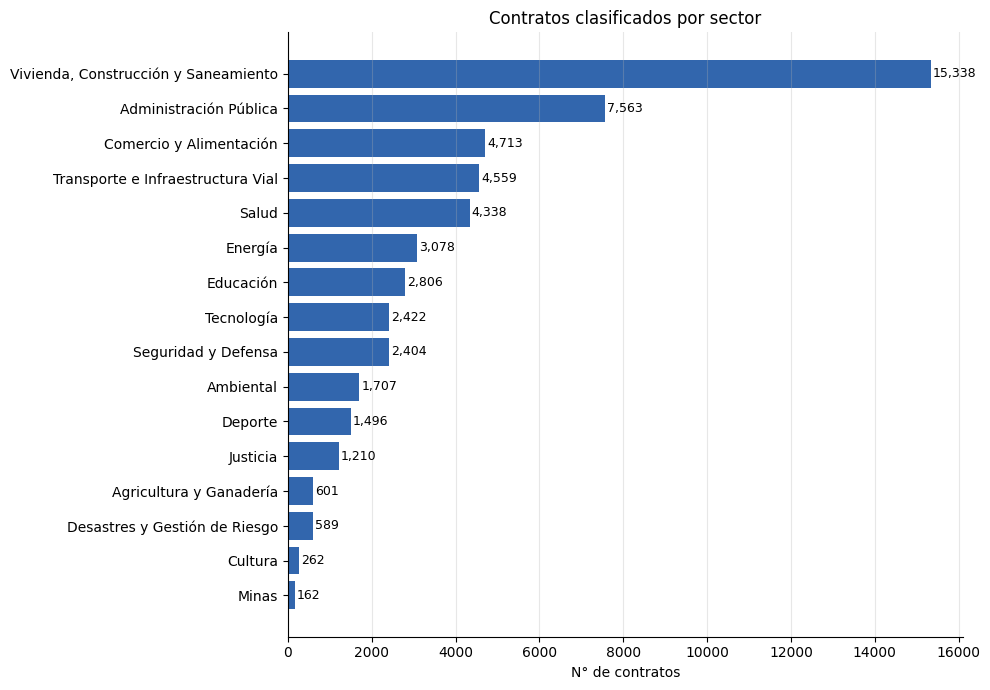

In [3]:
df_contratos = spark.sql("""
    SELECT sector_clasificado, COUNT(DISTINCT codigo_contrato) AS n_contratos
    FROM contratos
    WHERE sector_clasificado != 'Sin clasificar'
    GROUP BY sector_clasificado
    ORDER BY n_contratos ASC
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_contratos['sector_clasificado'], df_contratos['n_contratos'],
               color='#3266ad', edgecolor='none')

for bar, val in zip(bars, df_contratos['n_contratos']):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('N° de contratos')
ax.set_title('Contratos clasificados por sector')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('contratos_por_sector.png', dpi=150)
plt.show()

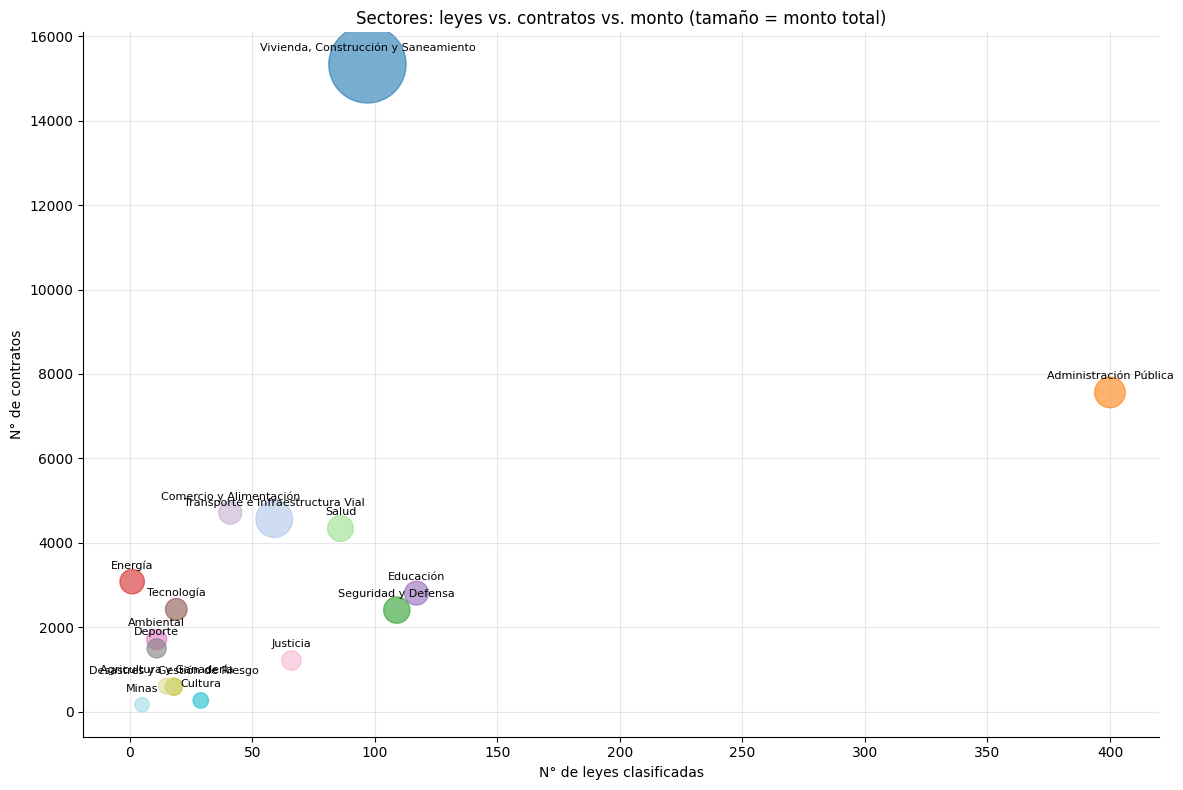

In [5]:
df_bubble = spark.sql("""
    SELECT
        c.sector_clasificado,
        COUNT(DISTINCT c.codigo_contrato)   AS n_contratos,
        SUM(c.monto_contratado_item)        AS monto_total,
        MAX(l.n_leyes)                      AS n_leyes
    FROM contratos c
    JOIN (
        SELECT sector_clasificado, COUNT(*) AS n_leyes
        FROM leyes
        WHERE sector_clasificado != 'Sin clasificar'
        GROUP BY sector_clasificado
    ) l ON c.sector_clasificado = l.sector_clasificado
    WHERE c.sector_clasificado != 'Sin clasificar'
    GROUP BY c.sector_clasificado
    ORDER BY monto_total DESC
""").toPandas()

fig, ax = plt.subplots(figsize=(12, 8))

max_monto = df_bubble['monto_total'].max()
sizes = (df_bubble['monto_total'] / max_monto * 3000) + 100

ax.scatter(df_bubble['n_leyes'], df_bubble['n_contratos'],
           s=sizes, alpha=0.6,
           c=range(len(df_bubble)), cmap='tab20')

for _, row in df_bubble.iterrows():
    ax.annotate(row['sector_clasificado'],
                (row['n_leyes'], row['n_contratos']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel('N° de leyes clasificadas')
ax.set_ylabel('N° de contratos')
ax.set_title('Sectores: leyes vs. contratos vs. monto (tamaño = monto total)')
ax.grid(True, alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('bubble_chart.png', dpi=150)
plt.show()

spark.stop()